# Regression after-class exercise — Predict the megawatts
### Individual exercise 

You are supporting day-ahead dispatch for a combined-cycle power plant. Given tomorrow's ambient conditions, the plant must decide how many megawatts it can safely promise to the grid.

**Learning outcomes**

1. Establish a regression baseline and interpret RMSE in engineering units.
2. Use cross-validation to control model complexity without consulting the final test set.
3. Train a neural network and explain why feature scaling is essential.
4. Connect learned relationships and residuals to process physics.
5. Write a defensible operational recommendation.


## 0. Setup 

Run the next two cells without editing them.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

from exercise_data import load_ccpp

def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5

plt.rcParams["figure.figsize"] = (9, 4)
print("Setup complete")

Setup complete


In [2]:
# Keep exercise_data.py in the same folder as this notebook.
# Keep this set to True during the exercise.
# The notebook will download the published dataset.
PREFER_REAL_DATA = True
ccpp = load_ccpp(prefer_real=PREFER_REAL_DATA)
print("Source:", ccpp.attrs["source"])
ccpp.head()

Loaded REAL CCPP data: 9568 rows × 5 columns
Source: REAL CCPP data


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


## 1. Understand the plant 

`PE` is net electrical output in MW. The predictors are ambient temperature (`AT`, °C), exhaust vacuum (`V`, cm Hg), ambient pressure (`AP`, mbar), and relative humidity (`RH`, %).

Before fitting a model, predict the sign of each relationship (Postive or Negative?). Think about air density, compressor mass flow, and condenser performance.

            AT        V       AP       RH       PE
count  9568.00  9568.00  9568.00  9568.00  9568.00
mean     19.65    54.31  1013.26    73.31   454.37
std       7.45    12.71     5.94    14.60    17.07
min       1.81    25.36   992.89    25.56   420.26
25%      13.51    41.74  1009.10    63.33   439.75
50%      20.34    52.08  1012.94    74.97   451.55
75%      25.72    66.54  1017.26    84.83   468.43
max      37.11    81.56  1033.30   100.16   495.76


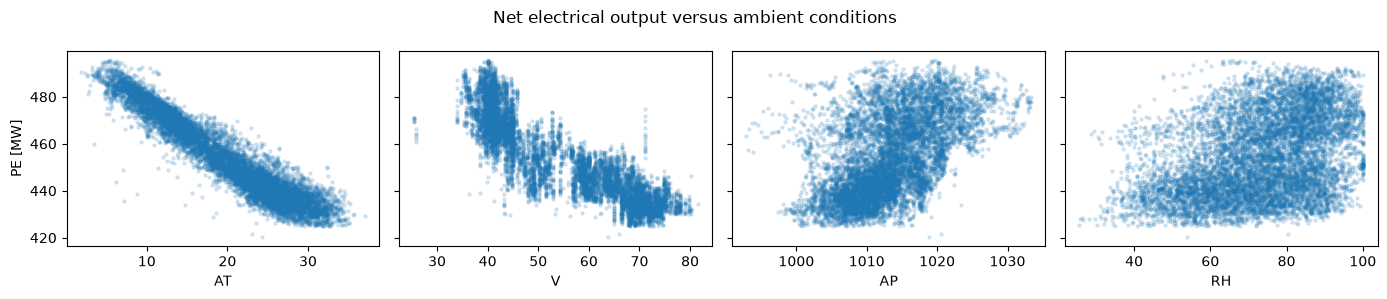

In [3]:
print(ccpp.describe().round(2))

fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=True)
for ax, column in zip(axes, ["AT", "V", "AP", "RH"]):
    ax.scatter(ccpp[column], ccpp["PE"], s=5, alpha=0.15)
    ax.set_xlabel(column)
axes[0].set_ylabel("PE [MW]")
plt.suptitle("Net electrical output versus ambient conditions")
plt.tight_layout()
plt.show()

### Written answer 1

Complete the table using the plots and engineering reasoning.

| Variable | Expected sign with PE | Physical explanation |
|---|---|---|
| AT | *your answer* | *your answer* |
| V | *your answer* | *your answer* |
| AP | *your answer* | *your answer* |
| RH | *your answer* | *your answer* |

Which variable appears most informative? Why should a scatter plot not be treated as causal proof?

> **Your answer:**

## 2. Establish a baseline and linear model

Reserve the final test data now. All development decisions must use only `X_train` and `y_train`.

In [ ]:
FEATURES = ["AT", "V", "AP", "RH"]
TARGET = "PE"

# TODO 1: create X and y, then reserve 25% of the rows as a final test set.
# Use random_state=0. Do not use X_test or y_test until Part 4.
X = ...
y = ...
X_train, X_test, y_train, y_test = ...

assert X_train.shape[1] == 4
assert len(X_train) + len(X_test) == len(ccpp)
assert set(X_train.index).isdisjoint(X_test.index)
print(f"Reserved {len(X_test)} final-test rows; {len(X_train)} rows remain for development.")

<details><summary>Hint for TODO 1</summary>

Use `ccpp[FEATURES]`, `ccpp[TARGET]`, and `train_test_split(..., test_size=0.25, random_state=0)`.

</details>

In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=0)
baseline = DummyRegressor(strategy="mean")
linear = LinearRegression()

# TODO 2: estimate development performance with five-fold cross-validation.
# cross_val_score(..., scoring="neg_root_mean_squared_error") returns negative RMSE.
baseline_cv_rmse = ...
linear_cv_rmse = ...

# TODO 3: fit linear regression on all development data and make a coefficient table.
linear.fit(...)
coefficient_table = ...

print(f"Mean baseline CV RMSE: {baseline_cv_rmse:.2f} MW")
print(f"Linear model CV RMSE:  {linear_cv_rmse:.2f} MW")
display(coefficient_table)

assert linear_cv_rmse < baseline_cv_rmse
assert list(coefficient_table.index) == FEATURES

<details><summary>Hints for TODOs 2–3</summary>

Use the negative of the mean returned by `cross_val_score`. Fit with `linear.fit(X_train, y_train)`. A coefficient table can be created with `pd.Series(linear.coef_, index=FEATURES).to_frame(...)`.

</details>

### Written answer 2

1. How much better is linear regression than always predicting the training mean?
2. Give the units and physical meaning of the `AT` coefficient.
3. Why is cross-validation error more useful than training error for estimating future performance?

> **Your answer:**

## 3. Control model complexity 

A vendor proposes a decision tree. Deeper trees fit more detailed rules, but may learn noise rather than plant behaviour.

In [ ]:
depths = [2, 4, 6, 8, 12, None]
rows = []

for depth in depths:
    # TODO 4: fit this tree on the development data.
    tree = ...
    tree.fit(...)

    # TODO 5: calculate training RMSE and mean five-fold CV RMSE.
    train_rmse = ...
    cv_rmse = ...
    rows.append({"depth": depth, "train_rmse": train_rmse, "cv_rmse": cv_rmse})

tree_results = pd.DataFrame(rows)
display(tree_results.round(3))

ax = tree_results.plot(x="depth", y=["train_rmse", "cv_rmse"], marker="o")
ax.set_ylabel("RMSE [MW]")
ax.set_title("Training fit versus cross-validated performance")
plt.show()

assert len(tree_results) == len(depths)
assert tree_results["train_rmse"].iloc[-1] <= tree_results["train_rmse"].iloc[0]

<details><summary>Hints for TODOs 4–5</summary>

Construct `DecisionTreeRegressor(max_depth=depth, random_state=0)`. Training RMSE uses predictions on `X_train`; cross-validation uses the same scoring and `cv` object as Part 2.

</details>

### Written answer 3

1. Why does training RMSE keep falling as depth increases?
2. At what depth does cross-validation stop improving?
3. Explain in one sentence why the unrestricted tree is not automatically the best model.

> **Your answer:**

In [ ]:
# TODO 6: choose the depth with the smallest cross-validation RMSE.
best_row_index = ...
best_depth = ...
best_depth = None if pd.isna(best_depth) else int(best_depth) # Pandas stores the depth column as floats and represents None as NaN; convert it back to the int-or-None format required by the decision tree.
best_tree_cv_rmse = ...
selected_tree = ...
selected_tree.fit(X_train, y_train)

print("Chosen tree depth:", best_depth)
print(f"Best tree CV RMSE: {best_tree_cv_rmse:.2f} MW")

assert best_tree_cv_rmse == tree_results["cv_rmse"].min()

<details><summary>Hint for TODO 6</summary>

Use `tree_results["cv_rmse"].idxmin()` to locate the best row. Extract its depth and create a new tree using that depth.

</details>

## 4. Train a neural network

A multi-layer perceptron (MLP) can learn nonlinear relationships without manually choosing polynomial terms. Gradient-based training is sensitive to feature scale: here `AP` is around 1013 while `AT` is around 20. Compare an unscaled network with the same network inside a scaling pipeline. An unscaled convergence warning is expected and is part of the lesson.

In [ ]:
unscaled_mlp = MLPRegressor(
    hidden_layer_sizes=(32,), max_iter=300, random_state=0
)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    unscaled_mlp_cv_rmse = -cross_val_score(
        unscaled_mlp, X_train, y_train, cv=cv,
        scoring="neg_root_mean_squared_error",
    ).mean()

# TODO 7: construct the scaled MLP pipeline described below.
# MLPRegressor settings: hidden_layer_sizes=(32,), max_iter=800,
# random_state=0, early_stopping=True, n_iter_no_change=15.
scaled_mlp = ...

# TODO 8: calculate its five-fold CV RMSE, then fit it on all development data.
scaled_mlp_cv_rmse = ...
scaled_mlp.fit(...)

development_scores = {
    "linear regression": linear_cv_rmse,
    "decision tree": best_tree_cv_rmse,
    "scaled neural network": scaled_mlp_cv_rmse,
}
selected_name = min(development_scores, key=development_scores.get)
selected_model = {
    "linear regression": linear,
    "decision tree": selected_tree,
    "scaled neural network": scaled_mlp,
}[selected_name]

print(f"Unscaled MLP CV RMSE: {unscaled_mlp_cv_rmse:.2f} MW")
print(f"Scaled MLP CV RMSE:   {scaled_mlp_cv_rmse:.2f} MW")
print("Development scores:", development_scores)
print("Selected final model:", selected_name)

assert np.isfinite(unscaled_mlp_cv_rmse)
assert np.isfinite(scaled_mlp_cv_rmse)
assert selected_name in development_scores

<details><summary>Hints for TODOs 7–8</summary>

Use `make_pipeline(StandardScaler(), MLPRegressor(...))`. Calculate CV RMSE with the same `cross_val_score`, `cv`, and scoring pattern used earlier. Fit with `scaled_mlp.fit(X_train, y_train)`.

</details>

### Written answer 4

1. Why does scaling help gradient-based training but matter much less to a decision tree?
2. How much did scaling change the MLP's CV RMSE?
3. Did the neural network beat both simpler models? Explain why “more complex” does not guarantee “better.”

> **Your answer:**

## 5. Open the final test set once

Your model choices are now fixed. Compare the baseline, linear model, selected tree, and scaled neural network on the held-out rows. Do not revise `selected_name` from this table.

In [ ]:
# This is the first section that uses the final test set.
models_for_test = {
    "mean baseline": baseline,
    "linear regression": linear,
    "selected tree": selected_tree,
    "scaled neural network": scaled_mlp,
}
test_rows = []

for name, model in models_for_test.items():
    # TODO 9: fit on all development data and calculate test RMSE and R².
    model.fit(...)
    prediction = ...
    test_rows.append({"model": name, "test_rmse": ..., "test_r2": ...})

test_results = pd.DataFrame(test_rows).set_index("model")
display(test_results.round(3))

assert len(test_results) == 4
assert np.isfinite(test_results.to_numpy()).all()

<details><summary>Hint for TODO 9</summary>

For each model, call `fit(X_train, y_train)`, predict `X_test`, then use `rmse(y_test, prediction)` and `r2_score(y_test, prediction)`.

</details>

### Written answer 5

1. Did the cross-validation ranking agree with the final test ranking?
2. Express the preselected model's typical error in MW and as an approximate percentage of a 455 MW plant.
3. Why would changing your model choice after reading this table make the reported performance optimistic?

> **Your answer:**

## 6. Diagnose and recommend

In [ ]:
selected_model.fit(X_train, y_train)
test_prediction = selected_model.predict(X_test)
residual = y_test - test_prediction

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(y_test, test_prediction, s=8, alpha=0.25)
limits = [y.min(), y.max()]
axes[0].plot(limits, limits, "k--")
axes[0].set(xlabel="Measured PE [MW]", ylabel="Predicted PE [MW]", title="Parity plot")

axes[1].scatter(X_test["AT"], residual, s=8, alpha=0.25)
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set(xlabel="Ambient temperature [°C]", ylabel="Residual [MW]", title="Residual check")
plt.tight_layout()
plt.show()

### Final recommendation — maximum 150 words

Write to the dispatch manager. State:

- which model you recommend;
- its final test RMSE and improvement over the baseline;
- whether the residual plot shows a serious remaining pattern;
- one validity limit, such as part-load operation or weather outside the training range;
- one monitoring action before deployment.

> **Your recommendation:**


## Optional regression extensions

These extensions use development cross-validation only. Do not use the final test table to tune them.

### A. Ridge and Lasso

Ordinary least squares minimises prediction error. Ridge additionally penalises squared coefficient size; Lasso penalises absolute coefficient size and may set coefficients to zero. Scaling is important because the penalty acts directly on coefficient magnitude.

In [ ]:
from sklearn.linear_model import Ridge, Lasso

alphas = [0.001, 0.01, 0.1, 1, 10, 100]
regularisation_rows = []

for family, estimator_class in [("Ridge", Ridge), ("Lasso", Lasso)]:
    for alpha in alphas:
        model = make_pipeline(
            StandardScaler(), estimator_class(alpha=alpha, max_iter=20_000)
        )
        # OPTIONAL TASK: calculate five-fold development CV RMSE.
        score = ...
        regularisation_rows.append(
            {"family": family, "alpha": alpha, "cv_rmse": score}
        )

regularisation_results = pd.DataFrame(regularisation_rows)
display(regularisation_results.round(3))

# OPTIONAL QUESTION: Which alpha is best for each family? Why is the improvement
# small when this dataset has only four informative predictors?

### B. Gradient-boosted trees

A random forest averages many largely independent trees. Gradient boosting instead builds trees sequentially, with each new tree correcting the current model's errors. XGBoost, LightGBM and CatBoost are highly optimised variants of this idea.

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

boosted_regressor = GradientBoostingRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=3, random_state=0
)

# OPTIONAL TASK: estimate its development RMSE with the existing five-fold CV.
boosted_cv_rmse = ...
print(f"Gradient boosting CV RMSE: {boosted_cv_rmse:.2f} MW")
print("Required-model development scores:", development_scores)

# OPTIONAL QUESTION: Does boosting improve enough to justify the additional
# complexity? Why must this decision be made without revisiting the test set?

# Supervised-learning algorithm map

This is a navigation guide, not a checklist of algorithms that must all be used. A strong workflow starts with a baseline, chooses a model family suited to the data, validates honestly, and only adds complexity when it improves the decision being made.

## Core families

### Concepts and coverage

| Family | Famous algorithms | Main idea | Where used here |
|---|---|---|---|
| Baselines | Mean predictor, majority class | Establish performance achieved without learning useful structure | Both required exercises |
| Linear regression | Ordinary least squares | Fit a weighted sum to a continuous target | Required regression |
| Regularised linear models | Ridge, Lasso, Elastic Net | Penalise large coefficients; Lasso may set some to zero | Optional regression |
| Linear classification | Logistic regression | Model class probability through a linear decision boundary | Required classification |
| Nearest neighbours | kNN | Predict from nearby training observations | Optional classification |
| Single trees | Decision tree | Recursively split variables into rule-like regions | Both required exercises |
| Bagged trees | Random forest | Average many decorrelated trees | Required classification |
| Boosted trees | Gradient Boosting, XGBoost, LightGBM, CatBoost | Build trees sequentially to correct earlier errors | Optional in both exercises |
| Support vector machines | Linear SVM, kernel SVM | Maximise the margin; kernels create nonlinear boundaries | Optional classification |
| Probabilistic classifiers | Gaussian, Multinomial and Bernoulli naïve Bayes | Combine feature likelihoods under a conditional-independence assumption | Optional classification |
| Neural networks | Multi-layer perceptron, deep networks | Learn successive nonlinear feature transformations | Required regression |

### Practical characteristics

| Family | Scaling? | Particularly useful when | Main caution |
|---|---|---|---|
| Baselines | No | Every problem | A sophisticated model is not valuable unless it beats the baseline |
| Linear regression | Usually not essential | Relationships are approximately linear and interpretation matters | Misses nonlinearities; coefficients can be misleading under collinearity |
| Regularised linear models | Yes | Features are numerous, correlated, or noisy | Regularisation strength must be selected by validation |
| Linear classification | Usually yes | An interpretable classifier or strong baseline is needed | Raw linear boundaries cannot represent interactions automatically |
| Nearest neighbours | Yes | Local geometry is meaningful and the dataset is not too large | Sensitive to scaling, irrelevant variables, and high dimension |
| Single trees | No | Nonlinear thresholds and interactions matter | Deep trees overfit easily |
| Bagged trees | No | Strong general-purpose tabular performance is needed | Less interpretable; probabilities may need calibration |
| Boosted trees | No | High predictive accuracy on structured or tabular data matters | More tuning; careless validation can overfit |
| Support vector machines | Yes | A medium-sized dataset has clear class separation | Kernel choice and hyperparameters matter; probabilities are indirect |
| Probabilistic classifiers | Usually no | A fast baseline is needed and class-conditional models are plausible | Conditional independence can be unrealistic |
| Neural networks | Yes | Complex nonlinear structure and sufficient data are available | Optimisation, scaling, and architecture choices matter |

## A practical selection sequence

1. Establish a task-appropriate baseline.
2. Fit an interpretable linear or logistic model.
3. Inspect validation errors and residuals for missing nonlinear structure.
4. Try a tree-based model for thresholds and interactions.
5. For tabular data, compare a random forest or gradient-boosted trees.
6. Use kNN or an SVM when distances or margins are meaningful and features can be scaled.
7. Use a neural network when nonlinear capacity is justified by the data and validation evidence.
8. Select the final operating threshold or regression model before opening the test set.

## Important distinctions

- **Regression versus classification** describes the target, not the model's sophistication. Trees, boosting, kNN, SVMs and neural networks have variants for both.
- **Bagging** trains models largely independently and averages them; random forests are the standard example.
- **Boosting** trains models sequentially so later learners focus on earlier errors.
- **Probability estimation and decisions are different.** A classifier ranks or estimates risk; an operational threshold converts that output into an action.
- **XGBoost, LightGBM and CatBoost** are widely used boosting libraries. The optional notebooks use scikit-learn's gradient boosting so no additional dependency is required; the underlying sequential-boosting idea is the transferable lesson.

## What remains outside these exercises

The package does not attempt a full treatment of multiclass classification, probability calibration, feature selection, uncertainty intervals, explainability methods, data drift, time-series validation, or deep-learning architectures. These are natural follow-on topics after students understand the workflow in the two required exercises.
